# Day 18 – NLP + Recommendation Systems
### 20-Day ML Revision Planner | Phase: Specialized ML

**Topics covered:**
1. Text Preprocessing
2. Bag of Words (BoW)
3. TF-IDF
4. N-grams
5. Naive Bayes, Logistic Regression, and Linear SVM for Text Classification
6. Recommendation Systems: Content-Based Filtering
7. Collaborative Filtering & the User-Item Matrix
8. Cosine Similarity & Matrix Factorization
9. The Cold-Start Problem
10. Mini Project: Movie Recommendation System
11. Interview Questions
12. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import fetch_20newsgroups

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Text Preprocessing

### What?
Raw text must be cleaned and normalized before it can be turned into numeric features:
- **Lowercasing**: "Great" and "great" should be treated as the same token.
- **Removing punctuation/special characters**: usually not meaningful for simple bag-of-words style models.
- **Tokenization**: splitting text into individual words (tokens).
- **Stopword removal**: discarding very common, low-information words ("the", "is", "and").
- **Stemming/Lemmatization**: reducing words to a common root/base form (e.g., "running" → "run") so different inflections aren't treated as entirely separate features.

### Why?
Without preprocessing, "Great!", "great", and "GREAT" would all become **different features**, needlessly fragmenting the vocabulary and diluting the signal each word-form could otherwise contribute.

### How?
A typical pipeline: lowercase → remove punctuation/numbers → tokenize → remove stopwords → (optionally) stem/lemmatize.


In [2]:
# Build a simple, dependency-light text preprocessing function
_stopwords_text = (
    "a an the and or but if is are was were be been being this that these those "
    "to of in on at for with as by from it its i you he she they we our your "
    "his her their not no do does did doing have has had having so such very"
)
STOPWORDS = set(_stopwords_text.split())

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation/numbers
    tokens = text.split()                            # simple whitespace tokenization
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]  # remove stopwords + single chars
    return ' '.join(tokens)

sample_reviews = [
    "This movie was absolutely GREAT! I loved it so much.",
    "Terrible film, I would not recommend it to anyone.",
    "It's an okay movie, nothing special but not bad either.",
    "Amazing acting and a fantastic story!!! Best movie of the year.",
    "Waste of time. The plot made no sense at all."
]

print("Before vs After preprocessing:\n")
for review in sample_reviews:
    print(f"BEFORE: {review}")
    print(f"AFTER:  {preprocess_text(review)}\n")


Before vs After preprocessing:

BEFORE: This movie was absolutely GREAT! I loved it so much.
AFTER:  movie absolutely great loved much

BEFORE: Terrible film, I would not recommend it to anyone.
AFTER:  terrible film would recommend anyone

BEFORE: It's an okay movie, nothing special but not bad either.
AFTER:  okay movie nothing special bad either

BEFORE: Amazing acting and a fantastic story!!! Best movie of the year.
AFTER:  amazing acting fantastic story best movie year

BEFORE: Waste of time. The plot made no sense at all.
AFTER:  waste time plot made sense all



## 2. Bag of Words (BoW)

### What?
BoW represents each document as a vector of **word counts** — the vocabulary across all documents becomes the feature set, and each document is a row counting how many times each vocabulary word appears. **Word order is completely discarded** (hence "bag").

### Why?
This is the simplest way to convert variable-length text into a **fixed-length numeric vector** that standard ML models (Naive Bayes, Logistic Regression, SVM — all covered on Days 5/6/8) can consume directly.

### How?
`CountVectorizer` in sklearn builds the vocabulary and produces the count matrix (typically a **sparse matrix**, since most documents contain only a small fraction of the total vocabulary).


In [3]:
# Bag of Words demonstration
preprocessed_reviews = [preprocess_text(r) for r in sample_reviews]

count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(preprocessed_reviews)

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())
print(f"Vocabulary size: {len(count_vectorizer.get_feature_names_out())}")
print("\nBag of Words matrix (rows=documents, columns=word counts):")
print(bow_df)


Vocabulary size: 27

Bag of Words matrix (rows=documents, columns=word counts):
   absolutely  acting  all  amazing  anyone  bad  best  either  fantastic  \
0           1       0    0        0       0    0     0       0          0   
1           0       0    0        0       1    0     0       0          0   
2           0       0    0        0       0    1     0       1          0   
3           0       1    0        1       0    0     1       0          1   
4           0       0    1        0       0    0     0       0          0   

   film  ...  plot  recommend  sense  special  story  terrible  time  waste  \
0     0  ...     0          0      0        0      0         0     0      0   
1     1  ...     0          1      0        0      0         1     0      0   
2     0  ...     0          0      0        1      0         0     0      0   
3     0  ...     0          0      0        0      1         0     0      0   
4     0  ...     1          0      1        0      0         0

## 3. TF-IDF (Term Frequency-Inverse Document Frequency)

### What?
TF-IDF improves on plain BoW by **weighting words by how informative they are**, not just how often they appear:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

- **TF (Term Frequency)**: how often term $t$ appears in document $d$.
- **IDF (Inverse Document Frequency)**: $\log\left(\frac{N}{1 + \text{DF}(t)}\right)$, where $N$ = total documents, $\text{DF}(t)$ = number of documents containing $t$. Words appearing in **many** documents get a **lower** IDF (less discriminative).

### Why?
A word like "movie" might appear in every review (high TF, but useless for distinguishing sentiment), while a word like "fantastic" appears rarely but is highly informative when it does. TF-IDF **downweights common words and upweights rare, distinctive ones** — automatically achieving something like a smarter, continuous version of stopword removal.

### How?
`TfidfVectorizer` combines tokenization, counting, and TF-IDF weighting in one step.


In [4]:
# TF-IDF demonstration, compared directly against BoW for the same word
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_reviews)

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("TF-IDF matrix (rows=documents, columns=TF-IDF weighted scores):")
print(tfidf_df.round(3))

# Compare a common-ish word vs a rare, distinctive word
if 'movie' in bow_df.columns and 'fantastic' in bow_df.columns:
    print("\nComparison for 'movie' (appears in most documents) vs 'fantastic' (appears in only one):")
    print(f"  'movie'    -- BoW counts: {bow_df['movie'].tolist()}, TF-IDF: {tfidf_df['movie'].round(3).tolist()}")
    print(f"  'fantastic'-- BoW counts: {bow_df['fantastic'].tolist()}, TF-IDF: {tfidf_df['fantastic'].round(3).tolist()}")
    print("\n--> 'fantastic' gets a relatively HIGHER TF-IDF weight where it appears, since it's rare")
    print("    and therefore more discriminative than a word like 'movie' that shows up everywhere.")


TF-IDF matrix (rows=documents, columns=TF-IDF weighted scores):
   absolutely  acting    all  amazing  anyone    bad   best  either  \
0       0.474   0.000  0.000    0.000   0.000  0.000  0.000   0.000   
1       0.000   0.000  0.000    0.000   0.447  0.000  0.000   0.000   
2       0.000   0.000  0.000    0.000   0.000  0.428  0.000   0.428   
3       0.000   0.394  0.000    0.394   0.000  0.000  0.394   0.000   
4       0.000   0.000  0.408    0.000   0.000  0.000  0.000   0.000   

   fantastic   film  ...   plot  recommend  sense  special  story  terrible  \
0      0.000  0.000  ...  0.000      0.000  0.000    0.000  0.000     0.000   
1      0.000  0.447  ...  0.000      0.447  0.000    0.000  0.000     0.447   
2      0.000  0.000  ...  0.000      0.000  0.000    0.428  0.000     0.000   
3      0.394  0.000  ...  0.000      0.000  0.000    0.000  0.394     0.000   
4      0.000  0.000  ...  0.408      0.000  0.408    0.000  0.000     0.000   

    time  waste  would   year  
0 

## 4. N-grams

### What?
Instead of treating each **single word** (unigram) as a feature, **N-grams** capture sequences of $N$ consecutive words:
- **Unigram**: "not", "good" (separate features)
- **Bigram**: "not good" (one feature — captures the negation!)
- **Trigram**: "not very good" (three-word sequences)

### Why?
Plain BoW/unigram TF-IDF **loses word order entirely** — "not good" and "good not" would produce identical unigram features, and critically, "not good" would look similar to "good" alone (since "not" might even be a stopword!). Bigrams/trigrams help capture **local context and negation**, which single words miss.

### How?
`CountVectorizer(ngram_range=(1, 2))` includes both unigrams AND bigrams; `(2, 2)` would include ONLY bigrams.


In [5]:
# N-grams demonstration: show how bigrams capture negation that unigrams miss
texts_negation = ["this movie is good", "this movie is not good"]

unigram_vec = CountVectorizer(ngram_range=(1, 1))
unigram_matrix = unigram_vec.fit_transform(texts_negation)
print("UNIGRAM features:", unigram_vec.get_feature_names_out())
print(unigram_matrix.toarray())
print("--> 'good' appears in BOTH documents with the same count -- unigrams alone can't tell")
print("    these two OPPOSITE-meaning sentences apart very well.\n")

bigram_vec = CountVectorizer(ngram_range=(1, 2))
bigram_matrix = bigram_vec.fit_transform(texts_negation)
print("UNIGRAM + BIGRAM features:", bigram_vec.get_feature_names_out())
print(bigram_matrix.toarray())
print("--> The bigram 'not good' now exists as its OWN distinct feature, clearly distinguishing")
print("    the negated sentence from the positive one.")


UNIGRAM features: ['good' 'is' 'movie' 'not' 'this']
[[1 1 1 0 1]
 [1 1 1 1 1]]
--> 'good' appears in BOTH documents with the same count -- unigrams alone can't tell
    these two OPPOSITE-meaning sentences apart very well.

UNIGRAM + BIGRAM features: ['good' 'is' 'is good' 'is not' 'movie' 'movie is' 'not' 'not good' 'this'
 'this movie']
[[1 1 1 0 1 1 0 0 1 1]
 [1 1 0 1 1 1 1 1 1 1]]
--> The bigram 'not good' now exists as its OWN distinct feature, clearly distinguishing
    the negated sentence from the positive one.


## 5. Naive Bayes, Logistic Regression, and Linear SVM for Text Classification

### What?
Once text is vectorized (BoW/TF-IDF), it becomes a standard tabular classification problem — the same algorithms from Days 5/6/8 apply directly:
- **Multinomial Naive Bayes**: assumes each feature (word count) follows a multinomial distribution per class; extremely fast, a strong classic baseline for text (recall Day 6's Naive Bayes, adapted for count data).
- **Logistic Regression**: works well on high-dimensional, sparse TF-IDF vectors; coefficients indicate which words push toward which class (recall Day 6's log-odds interpretation).
- **Linear SVM**: often performs excellently on text — high-dimensional sparse data is exactly the setting where a **linear** decision boundary (no kernel needed, recall Day 8) tends to work very well.

### Why?
Text data is typically **very high-dimensional** (thousands of vocabulary words) but **sparse** (each document only uses a small fraction of the vocabulary) — these three models all handle that combination efficiently and are standard, fast, strong baselines before reaching for deep learning.

### How?
Fit any of these directly on the TF-IDF (or BoW) matrix — no additional preprocessing needed beyond the vectorization itself.


In [6]:
# Build a realistic synthetic text classification dataset: baseball vs. space articles
# (Generated from topic-specific vocabulary so the notebook runs without needing external downloads.)
np.random.seed(11)

baseball_vocab = ["pitcher", "batter", "home run", "inning", "baseball", "stadium", "coach",
                   "team", "season", "league", "bat", "glove", "strike", "ball", "outfield",
                   "score", "game", "player", "manager", "championship", "diamond", "dugout"]
space_vocab = ["rocket", "orbit", "satellite", "astronaut", "planet", "galaxy", "telescope",
                "spacecraft", "launch", "nasa", "mission", "moon", "mars", "star", "universe",
                "gravity", "shuttle", "solar", "cosmos", "asteroid", "nebula", "spacewalk"]

def generate_document(vocab, n_words=40):
    return ' '.join(np.random.choice(vocab, size=n_words, replace=True))

n_docs_per_class = 150
baseball_docs = [generate_document(baseball_vocab) for _ in range(n_docs_per_class)]
space_docs = [generate_document(space_vocab) for _ in range(n_docs_per_class)]

X_text = baseball_docs + space_docs
y_text = np.array([0]*n_docs_per_class + [1]*n_docs_per_class)
target_names = ['baseball', 'space']

print(f"Dataset: {len(X_text)} documents, categories: {target_names}")
print(f"\nExample baseball document (truncated):\n{X_text[0][:200]}...")
print(f"\nExample space document (truncated):\n{X_text[-1][:200]}...")


Dataset: 300 documents, categories: ['baseball', 'space']

Example baseball document (truncated):
game player ball strike batter team manager ball game pitcher ball strike baseball home run strike batter bat stadium dugout team diamond player player inning coach glove manager manager pitcher score...

Example space document (truncated):
asteroid launch cosmos orbit shuttle satellite mars rocket spacecraft telescope solar shuttle orbit asteroid launch satellite mission spacecraft mission galaxy nasa gravity universe solar gravity orbi...


In [7]:
# Vectorize with TF-IDF and split into train/test
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.25, random_state=42, stratify=y_text)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.get_feature_names_out())}")


TF-IDF matrix shape (train): (225, 1014)
Vocabulary size: 1014


                         Accuracy
Model                            
Multinomial Naive Bayes       1.0
Logistic Regression           1.0
Linear SVM                    1.0


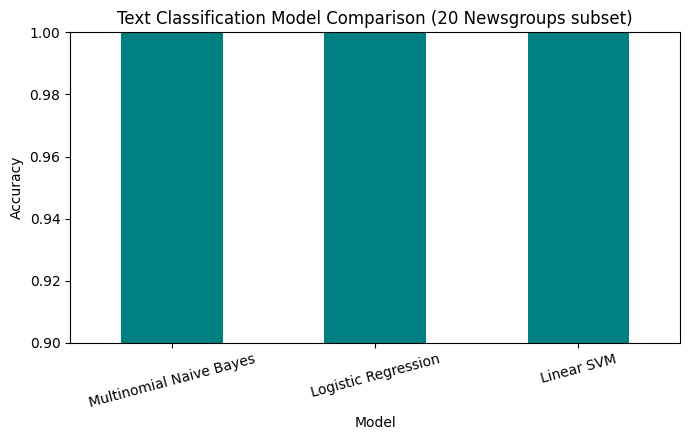

In [8]:
# Train and compare Naive Bayes, Logistic Regression, and Linear SVM on the TF-IDF features
text_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC()
}

text_results = []
for name, model in text_models.items():
    model.fit(X_train_tfidf, y_train_text)
    preds = model.predict(X_test_tfidf)
    text_results.append({'Model': name, 'Accuracy': accuracy_score(y_test_text, preds)})

text_results_df = pd.DataFrame(text_results).set_index('Model')
print(text_results_df.round(4))

text_results_df.plot(kind='bar', figsize=(7, 4.5), legend=False, ylim=(0.9, 1.0), color='teal')
plt.title("Text Classification Model Comparison (20 Newsgroups subset)")
plt.ylabel("Accuracy"); plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [9]:
# Interpret Logistic Regression's most influential words per class (log-odds intuition from Day 6)
log_reg_text = text_models['Logistic Regression']
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg_text.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:]
top_negative_idx = np.argsort(coefficients)[:10]

print(f"Top words pushing toward '{target_names[1]}':")
for idx in reversed(top_positive_idx):
    print(f"  {feature_names[idx]:20s}  coef={coefficients[idx]:.3f}")

print(f"\nTop words pushing toward '{target_names[0]}':")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:20s}  coef={coefficients[idx]:.3f}")


Top words pushing toward 'space':
  solar                 coef=0.977
  mars                  coef=0.948
  telescope             coef=0.943
  launch                coef=0.925
  cosmos                coef=0.916
  shuttle               coef=0.903
  mission               coef=0.902
  spacecraft            coef=0.899
  universe              coef=0.897
  nebula                coef=0.887

Top words pushing toward 'baseball':
  dugout                coef=-0.987
  strike                coef=-0.927
  team                  coef=-0.921
  player                coef=-0.920
  inning                coef=-0.902
  outfield              coef=-0.895
  glove                 coef=-0.894
  league                coef=-0.892
  bat                   coef=-0.879
  ball                  coef=-0.879


## 6. Recommendation Systems: Content-Based Filtering

### What?
**Content-based filtering** recommends items **similar to what a user has liked before**, based on **item attributes/content** (e.g., a movie's genre, description, cast). It builds a profile of "what this user likes" from the **content features** of items they've engaged with.

### Why?
- Doesn't need data from **other** users — works well even for a brand-new item (as long as it has content/features), unlike collaborative filtering (next section).
- Naturally **explainable**: "recommended because it's similar to X, which you liked" (e.g., shared genre, similar plot description).

### How?
1. Represent each item's content as a feature vector (e.g., TF-IDF of its description/genres — directly reusing this day's text-vectorization tools!).
2. Compute similarity (typically **cosine similarity**, below) between items.
3. For a user who liked item $A$, recommend the items most similar to $A$.


## 7. Collaborative Filtering & the User-Item Matrix

### What?
**Collaborative filtering (CF)** recommends items based on **patterns across many users' behavior**, without needing to know anything about item *content* — it relies purely on the **user-item interaction matrix** (rows = users, columns = items, values = ratings/interactions).

Two main flavors:
- **User-based CF**: find users **similar to you** (based on overlapping rating patterns), recommend items **they** liked that you haven't seen.
- **Item-based CF**: find items **similar to ones you've liked** (based on how OTHER users rated them together), recommend those.

### Why?
CF can discover **surprising, non-obvious connections** ("users who liked X also liked Y") that pure content-based filtering, limited to explicit item attributes, would never find — this is the classic "Amazon/Netflix recommendation" approach.

### How?
The **user-item matrix** is typically **extremely sparse** (most users haven't rated most items) — most CF techniques (including matrix factorization, below) are designed specifically to handle and exploit this sparsity.


User-Item Ratings Matrix (NaN = not yet rated):
        Movie_A  Movie_B  Movie_C  Movie_D  Movie_E  Movie_F
User_1      2.0      5.0      NaN      2.0      NaN      5.0
User_2      2.0      NaN      2.0      3.0      1.0      2.0
User_3      1.0      NaN      NaN      5.0      4.0      1.0
User_4      5.0      4.0      1.0      NaN      NaN      2.0
User_5      1.0      5.0      NaN      4.0      NaN      NaN
User_6      NaN      2.0      NaN      NaN      2.0      NaN
User_7      NaN      3.0      NaN      4.0      5.0      3.0
User_8      1.0      2.0      NaN      1.0      NaN      4.0


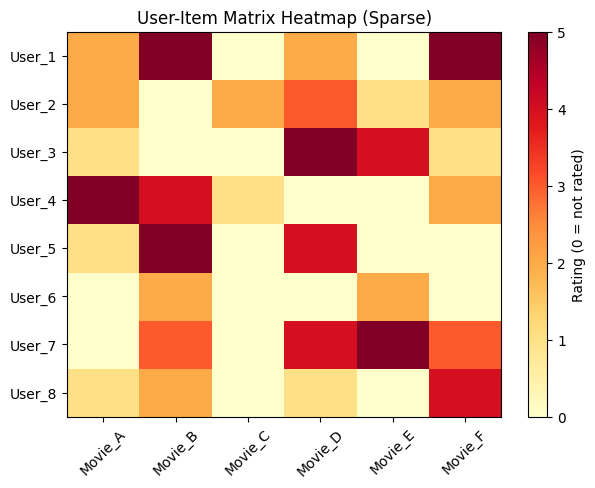


Sparsity: 37.5% of entries are missing (unrated)
--> Real-world platforms (Netflix, Amazon) have FAR higher sparsity, often >99%.


In [10]:
# Build and visualize a small user-item ratings matrix
np.random.seed(10)
users = [f"User_{i}" for i in range(1, 9)]
movies = [f"Movie_{chr(65+i)}" for i in range(6)]  # Movie_A through Movie_F

# Simulate ratings with some missing values (sparse, realistic)
full_ratings = np.random.randint(1, 6, (8, 6)).astype(float)
mask = np.random.rand(8, 6) < 0.35  # 35% missing
full_ratings[mask] = np.nan

ratings_df = pd.DataFrame(full_ratings, index=users, columns=movies)
print("User-Item Ratings Matrix (NaN = not yet rated):")
print(ratings_df)

plt.figure(figsize=(7, 5))
plt.imshow(ratings_df.fillna(0), cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Rating (0 = not rated)')
plt.xticks(range(len(movies)), movies, rotation=45)
plt.yticks(range(len(users)), users)
plt.title("User-Item Matrix Heatmap (Sparse)")
plt.show()

sparsity = ratings_df.isna().sum().sum() / ratings_df.size
print(f"\nSparsity: {sparsity:.1%} of entries are missing (unrated)")
print("--> Real-world platforms (Netflix, Amazon) have FAR higher sparsity, often >99%.")


## 8. Cosine Similarity & Matrix Factorization

### What?
- **Cosine similarity** (recall Day 1): measures the angle between two vectors, ignoring magnitude — perfect for comparing rating patterns or content vectors regardless of how many items two users have rated or how verbose two item descriptions are.
  $$\text{sim}(A, B) = \frac{A \cdot B}{\|A\|\|B\|}$$
- **Matrix Factorization**: decomposes the sparse user-item matrix $R$ (users × items) into two smaller, dense matrices — a **user-factor matrix** $U$ (users × $k$ latent factors) and an **item-factor matrix** $V$ (items × $k$ latent factors) — such that $R \approx U V^T$. The $k$ **latent factors** are learned, abstract dimensions (not necessarily human-interpretable, e.g., might loosely correspond to "action-ness" or "critical acclaim").

### Why?
- Cosine similarity is the standard tool to compare **rating patterns between users** (user-based CF) or **item descriptions** (content-based filtering) — robust to differing scales/lengths.
- Matrix factorization **fills in the missing ratings** by learning compact latent representations, capturing patterns simple similarity metrics might miss, and is the technique that famously won the Netflix Prize competition.

### How?
`TruncatedSVD` (Truncated Singular Value Decomposition, related to Day 12's PCA eigen-decomposition) is a common, simple way to perform matrix factorization in practice.


In [11]:
# Cosine similarity between users (fill NaN with 0 for this simple demo -- a common naive approach)
ratings_filled = ratings_df.fillna(0)
user_similarity = cosine_similarity(ratings_filled)
user_sim_df = pd.DataFrame(user_similarity, index=users, columns=users)

print("User-User Cosine Similarity Matrix:")
print(user_sim_df.round(3))

# Find the most similar user to User_1 (excluding themselves)
target_user = 'User_1'
similar_users = user_sim_df[target_user].drop(target_user).sort_values(ascending=False)
print(f"\nUsers most similar to {target_user}:")
print(similar_users)


User-User Cosine Similarity Matrix:
        User_1  User_2  User_3  User_4  User_5  User_6  User_7  User_8
User_1   1.000   0.560   0.340   0.774   0.709   0.464   0.650   0.952
User_2   0.560   1.000   0.748   0.503   0.461   0.151   0.638   0.591
User_3   0.340   0.748   1.000   0.157   0.494   0.431   0.854   0.325
User_4   0.774   0.503   0.157   1.000   0.569   0.417   0.346   0.660
User_5   0.709   0.461   0.494   0.569   1.000   0.546   0.623   0.493
User_6   0.464   0.151   0.431   0.417   0.546   1.000   0.736   0.302
User_7   0.650   0.638   0.854   0.346   0.623   0.736   1.000   0.611
User_8   0.952   0.591   0.325   0.660   0.493   0.302   0.611   1.000

Users most similar to User_1:
User_8    0.9518
User_4    0.7744
User_5    0.7091
User_7    0.6496
User_2    0.5599
User_6    0.4642
User_3    0.3404
Name: User_1, dtype: float64


In [12]:
# Matrix Factorization via TruncatedSVD -- fill in missing ratings using learned latent factors
n_latent_factors = 3
svd = TruncatedSVD(n_components=n_latent_factors, random_state=42)

user_factors = svd.fit_transform(ratings_filled)   # users x k
item_factors = svd.components_.T                    # items x k

reconstructed_ratings = user_factors @ item_factors.T
reconstructed_df = pd.DataFrame(reconstructed_ratings, index=users, columns=movies)

print(f"Latent factors used: {n_latent_factors}")
print("\nOriginal ratings (NaN = missing):")
print(ratings_df.round(2))
print("\nReconstructed ratings (predictions for ALL user-item pairs, including originally missing ones):")
print(reconstructed_df.round(2))

# Show specifically what we'd now predict for previously-missing entries
print("\nPredicted ratings for PREVIOUSLY MISSING entries (recommendation candidates):")
missing_mask = ratings_df.isna()
for user in users[:3]:
    for movie in movies:
        if missing_mask.loc[user, movie]:
            print(f"  {user}, {movie}: predicted rating = {reconstructed_df.loc[user, movie]:.2f}")


Latent factors used: 3

Original ratings (NaN = missing):
        Movie_A  Movie_B  Movie_C  Movie_D  Movie_E  Movie_F
User_1      2.0      5.0      NaN      2.0      NaN      5.0
User_2      2.0      NaN      2.0      3.0      1.0      2.0
User_3      1.0      NaN      NaN      5.0      4.0      1.0
User_4      5.0      4.0      1.0      NaN      NaN      2.0
User_5      1.0      5.0      NaN      4.0      NaN      NaN
User_6      NaN      2.0      NaN      NaN      2.0      NaN
User_7      NaN      3.0      NaN      4.0      5.0      3.0
User_8      1.0      2.0      NaN      1.0      NaN      4.0

Reconstructed ratings (predictions for ALL user-item pairs, including originally missing ones):
        Movie_A  Movie_B  Movie_C  Movie_D  Movie_E  Movie_F
User_1     3.22     4.82     0.62     1.98     0.36     4.14
User_2     1.21     0.41     0.58     1.98     1.83     2.77
User_3    -0.11     0.40     0.23     4.52     4.22     1.57
User_4     2.97     4.21     0.51     0.40    -0.96 

## 9. The Cold-Start Problem

### What?
**Cold-start** occurs when a recommender system has **little or no data** about a new user or new item:
- **New user cold-start**: a brand-new user has no rating history — collaborative filtering has nothing to base recommendations on.
- **New item cold-start**: a brand-new item has no ratings from any user yet — collaborative filtering can't place it relative to other items.

### Why?
This is a **fundamental limitation of pure collaborative filtering** — it relies entirely on historical interaction data, which by definition doesn't exist yet for new users/items.

### How to mitigate it?
- **Hybrid systems**: combine content-based filtering (works immediately for new items with known attributes) with collaborative filtering (kicks in once enough interaction data accumulates).
- **New users**: ask for initial preferences/onboarding surveys, use demographic-based defaults, or recommend generally popular items until enough personal data is collected.
- **New items**: rely on content-based similarity to already-popular items until the new item accumulates its own ratings.


In [13]:
# Demonstrate the cold-start problem directly
new_user_ratings = pd.Series([np.nan]*len(movies), index=movies, name='New_User')
print("A brand-new user's row in the user-item matrix:")
print(new_user_ratings)
print("\n--> Cosine similarity with ALL other users would be undefined/meaningless (all-zero vector) --")
print("    collaborative filtering has NOTHING to work with here. This is the cold-start problem,")
print("    and it's exactly why real systems combine CF with content-based or popularity-based fallbacks.")


A brand-new user's row in the user-item matrix:
Movie_A   NaN
Movie_B   NaN
Movie_C   NaN
Movie_D   NaN
Movie_E   NaN
Movie_F   NaN
Name: New_User, dtype: float64

--> Cosine similarity with ALL other users would be undefined/meaningless (all-zero vector) --
    collaborative filtering has NOTHING to work with here. This is the cold-start problem,
    and it's exactly why real systems combine CF with content-based or popularity-based fallbacks.


## 10. Mini Project — Movie Recommendation System (Content-Based)

**Goal:** Build a working content-based recommender using TF-IDF + cosine similarity on movie descriptions/genres, and conceptually connect it to collaborative filtering.


In [14]:
# Build a small movie dataset with descriptions/genres (content-based filtering input)
movies_data = pd.DataFrame({
    'title': ['Galaxy Warriors', 'Love in Paris', 'The Last Detective', 'Space Odyssey Reborn',
              'Romantic Getaway', 'Murder at Midnight', 'Alien Invasion', 'The Wedding Planner',
              'Cosmic Justice', 'Deadly Secrets'],
    'genre_description': [
        'action space war military spaceship battle',
        'romance love paris relationship drama',
        'mystery crime detective investigation thriller',
        'space scifi adventure exploration alien',
        'romance love vacation relationship comedy',
        'mystery crime murder thriller investigation',
        'action alien invasion war military scifi',
        'romance comedy wedding love relationship',
        'action space justice military scifi war',
        'mystery thriller crime secrets investigation'
    ]
})

print(movies_data)


                  title                               genre_description
0       Galaxy Warriors      action space war military spaceship battle
1         Love in Paris           romance love paris relationship drama
2    The Last Detective  mystery crime detective investigation thriller
3  Space Odyssey Reborn         space scifi adventure exploration alien
4      Romantic Getaway       romance love vacation relationship comedy
5    Murder at Midnight     mystery crime murder thriller investigation
6        Alien Invasion        action alien invasion war military scifi
7   The Wedding Planner        romance comedy wedding love relationship
8        Cosmic Justice         action space justice military scifi war
9        Deadly Secrets    mystery thriller crime secrets investigation


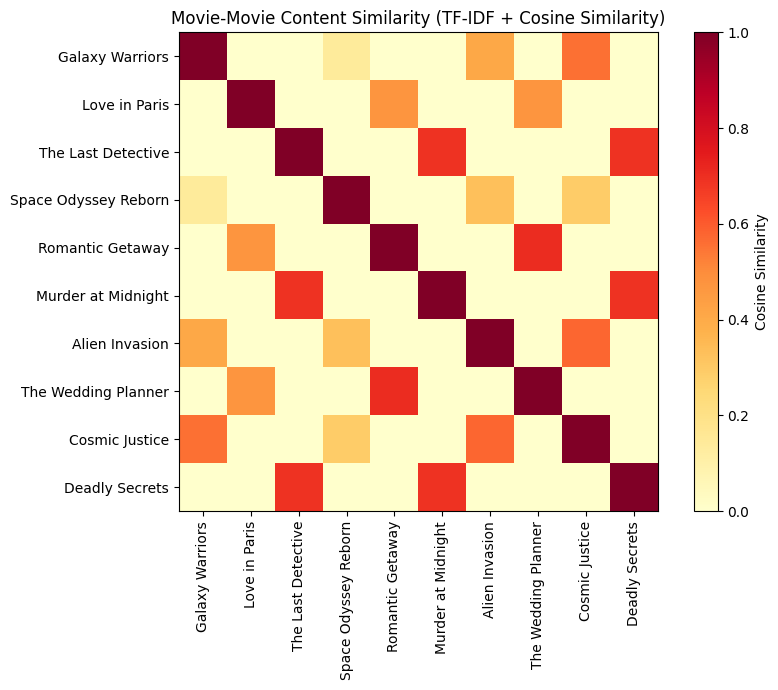

In [15]:
# Vectorize movie descriptions with TF-IDF, compute item-item cosine similarity
movie_tfidf_vectorizer = TfidfVectorizer()
movie_tfidf_matrix = movie_tfidf_vectorizer.fit_transform(movies_data['genre_description'])

movie_similarity = cosine_similarity(movie_tfidf_matrix)
movie_sim_df = pd.DataFrame(movie_similarity, index=movies_data['title'], columns=movies_data['title'])

plt.figure(figsize=(9, 7))
plt.imshow(movie_sim_df, cmap='YlOrRd')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(movies_data)), movies_data['title'], rotation=90)
plt.yticks(range(len(movies_data)), movies_data['title'])
plt.title("Movie-Movie Content Similarity (TF-IDF + Cosine Similarity)")
plt.tight_layout()
plt.show()


In [16]:
# Build the recommendation function
def recommend_movies(movie_title, similarity_df, top_n=3):
    similar_scores = similarity_df[movie_title].drop(movie_title).sort_values(ascending=False)
    return similar_scores.head(top_n)

# Test the recommender on a few movies
for test_movie in ['Galaxy Warriors', 'Love in Paris', 'Murder at Midnight']:
    recommendations = recommend_movies(test_movie, movie_sim_df, top_n=3)
    print(f"Because you watched '{test_movie}', we recommend:")
    for rec_title, score in recommendations.items():
        print(f"  -> {rec_title}  (similarity = {score:.3f})")
    print()


Because you watched 'Galaxy Warriors', we recommend:


  -> Cosmic Justice  (similarity = 0.556)
  -> Alien Invasion  (similarity = 0.408)
  -> Space Odyssey Reborn  (similarity = 0.138)

Because you watched 'Love in Paris', we recommend:
  -> Romantic Getaway  (similarity = 0.472)
  -> The Wedding Planner  (similarity = 0.472)
  -> Galaxy Warriors  (similarity = 0.000)

Because you watched 'Murder at Midnight', we recommend:
  -> The Last Detective  (similarity = 0.689)
  -> Deadly Secrets  (similarity = 0.689)
  -> Galaxy Warriors  (similarity = 0.000)



In [17]:
# Simulate a user profile: recommend based on MULTIPLE liked movies (average content profile)
liked_movies = ['Galaxy Warriors', 'Cosmic Justice']  # user liked two sci-fi/action movies
liked_indices = [movies_data[movies_data['title'] == m].index[0] for m in liked_movies]

user_profile_vector = movie_tfidf_matrix[liked_indices].mean(axis=0)
user_profile_vector = np.asarray(user_profile_vector)

similarity_to_profile = cosine_similarity(user_profile_vector, movie_tfidf_matrix)[0]
profile_similarity_series = pd.Series(similarity_to_profile, index=movies_data['title']).sort_values(ascending=False)

# Exclude already-liked movies from the final recommendation list
recommendations_for_user = profile_similarity_series.drop(liked_movies).head(3)

print(f"User liked: {liked_movies}")
print(f"\nTop recommendations based on their AGGREGATE content profile:")
print(recommendations_for_user)
print("\n--> This is exactly how a real content-based recommender builds a 'taste profile' from")
print("    multiple liked items, then finds unseen items closest to that profile.")


User liked: ['Galaxy Warriors', 'Cosmic Justice']

Top recommendations based on their AGGREGATE content profile:
title
Alien Invasion          0.5569
Space Odyssey Reborn    0.2433
Love in Paris           0.0000
dtype: float64

--> This is exactly how a real content-based recommender builds a 'taste profile' from
    multiple liked items, then finds unseen items closest to that profile.


## ML Connection Recap

| Concept | Connects to |
|---|---|
| TF-IDF | Day 3's statistics (frequency-based weighting) |
| Naive Bayes/Logistic Regression/SVM for text | Day 6/8's classification algorithms, applied to sparse high-dim text vectors |
| Cosine similarity | Day 1's dot product and vector norms |
| Matrix Factorization (TruncatedSVD) | Day 12's PCA/eigen-decomposition — closely related dimensionality-reduction machinery |
| User-item matrix sparsity | Day 13's curse of dimensionality (sparse, high-dimensional data) |


## 11. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What's the difference between Bag of Words and TF-IDF?**
   *Hint: BoW uses raw counts; TF-IDF additionally downweights common words and upweights rare, distinctive ones via the IDF term.*

2. **Why do bigrams/trigrams sometimes outperform unigrams for text classification?**
   *Hint: captures local word order and context (e.g., negation: "not good" vs "good"), which unigrams alone discard.*

3. **Compare content-based filtering and collaborative filtering.**
   *Hint: content-based uses item attributes/features and a single user's history; collaborative filtering uses patterns across MANY users' interactions, without needing item content.*

4. **What is the cold-start problem, and how would you address it?**
   *Hint: no data for new users/items; mitigate via hybrid systems, content-based fallback for new items, onboarding/popularity-based defaults for new users.*

5. **Why is cosine similarity preferred over Euclidean distance for comparing text/rating vectors?**
   *Hint: cosine similarity ignores magnitude/length differences (e.g., a user who rated many items vs few, or a long vs short document), focusing purely on the "direction"/pattern of the vector.*

6. **Explain matrix factorization in the context of recommendation systems.**
   *Hint: decomposes the sparse user-item matrix into lower-dimensional user-factor and item-factor matrices whose product approximates/fills in the original matrix, including previously missing entries.*

7. **(Bonus) Why might Multinomial Naive Bayes be a surprisingly strong baseline for text classification despite its "naive" independence assumption?**
   *Hint: text features (word counts) are extremely high-dimensional and the independence assumption, while technically wrong (words DO correlate), still yields a reasonable approximate ranking of class probabilities cheaply and fast — echoes Day 3/6's broader Naive Bayes discussion.*


## 12. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain the standard text preprocessing pipeline (lowercase, remove punctuation, tokenize, stopwords, stemming/lemmatization).
- [ ] Explain Bag of Words and TF-IDF, and why TF-IDF often works better.
- [ ] Explain N-grams and give an example where bigrams capture something unigrams miss.
- [ ] Train and compare Naive Bayes, Logistic Regression, and Linear SVM on TF-IDF features.
- [ ] Explain content-based filtering vs. collaborative filtering, including the user-item matrix.
- [ ] Explain cosine similarity and why it's preferred for text/rating comparisons.
- [ ] Explain matrix factorization and how it addresses the sparsity of the user-item matrix.
- [ ] Explain the cold-start problem and at least two mitigation strategies.
- [ ] Build a content-based movie recommender from movie descriptions using TF-IDF + cosine similarity.

### 📌 Daily Output (per the planner)
A **working recommendation prototype** (Section 10, Mini Project: Movie Recommendation System) — a content-based recommender built from movie genre/description text via TF-IDF vectorization and cosine similarity, capable of recommending similar movies to a single liked title AND building an aggregate user taste profile from multiple liked movies, plus a conceptual + hands-on tour of collaborative filtering via the user-item matrix and matrix factorization (Sections 7-8).

Close this notebook and re-explain, from memory, why TF-IDF downweights the word "movie" in a set of movie reviews but upweights a rare word like "fantastic" — that's the real test of Day 18 mastery.
